In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import gsw
import cmocean as cm
import matplotlib.colors as colors

In [2]:
import nc_time_axis

In [3]:
from dask.distributed import Client
import dask
import os

# os.environ["MALLOC_TRIM_THRESHOLD_"] = str(dask.config.get("distributed.nanny.environ.MALLOC_TRIM_THRESHOLD_"))
client =Client(n_workers=8, threads_per_worker=1, memory_limit="4 GiB",local_directory="/home1/scratch/jmartine/tmp")

In [4]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 8,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:49796,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33006,Total threads: 1
Dashboard: http://127.0.0.1:40777/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:40561,


In [5]:
out_path_creg = '/home/datawork-lops-drakkarcom/SIMULATION-OUTPUTS/FREDY/CONFIGS/CREG12.L75/CREG12.L75-REF08-MEAN/1m/2014'

In [6]:
grid_path = "/home/datawork-lops-drakkarcom/SIMULATION-OUTPUTS/FREDY/CONFIGS/CREG12.L75/GRID/"
gridh = xr.open_mfdataset(grid_path+'CREG12.L75-REF08_mesh_hgr.nc',chunks={'x':300,'y':300},parallel=True,decode_coords=False)
gridz = xr.open_mfdataset(grid_path+'CREG12.L75-REF08_mesh_zgr.nc',chunks={'x':300,'y':300},parallel=True,decode_coords=False)

In [7]:
area = (gridh.e1t*gridh.e2t).squeeze()
area

<xarray.DataArray (y: 1801, x: 1580)> Size: 23MB
dask.array<getitem, shape=(1801, 1580), dtype=float64, chunksize=(300, 300), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x

In [8]:
CREG_gridT_ds = xr.open_mfdataset(out_path_creg+'/*y2014m*.5d_gridT.nc',chunks={'x':300,'y':300},parallel=True,decode_coords=False)

In [9]:
CREG_gridICE_ds = xr.open_mfdataset(out_path_creg+'/*y2014m*.5d_icemod.nc',chunks={'x':300,'y':300},parallel=True,decode_coords=False)

In [10]:
salt = CREG_gridT_ds.vosaline.where(CREG_gridT_ds.vosaline>10,np.nan)
temp = CREG_gridT_ds.votemper.where(CREG_gridT_ds.vosaline>10,np.nan)

In [11]:
siconc = CREG_gridICE_ds.siconc

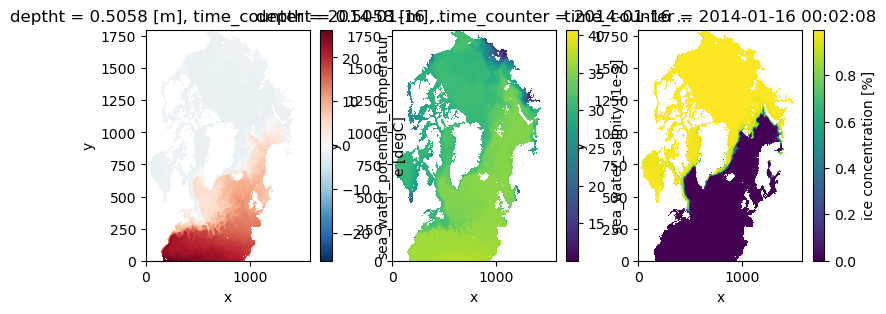

In [12]:
fig,ax = plt.subplots(1,3,figsize=(9,3))
temp.isel(time_counter=0,deptht=0).plot(ax=ax[0])
salt.isel(time_counter=0,deptht=0).plot(ax=ax[1])
siconc.isel(time_counter=0).plot(ax=ax[2])

# Mask domain

Here we mask the domain and area to account for the fact that as depth increases, the likely area to have values decreases. This is important in the area weighted average. 

In [13]:
domain_mask = xr.ones_like(salt)
domain_mask = domain_mask.where(salt>10,0)

In [14]:
mask = siconc.where(siconc<=0.8,0).where(siconc>0,0).astype(bool)
mask_area = (area * mask * domain_mask)
mask_area = mask_area.where(mask_area!=0,np.nan)
total_area = mask_area.sum(("x","y"))

In [15]:
# Area weighted average
temp_mean = ((temp * mask_area).sum(("x","y"))/total_area).compute()
salt_mean = ((salt * mask_area).sum(("x","y"))/total_area).compute()

/home1/datahome/jmartine/datawork/conda-env/jupyter-lab/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home1/datahome/jmartine/datawork/conda-env/jupyter-lab/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home1/datahome/jmartine/datawork/conda-env/jupyter-lab/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home1/datahome/jmartine/datawork/conda-env/jupyter-lab/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home1/datahome/jmartine/datawork/conda-env/jupyter-lab/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home1/datahome/jmartine/dataw

[None, None]

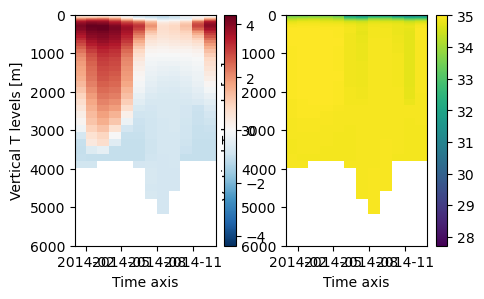

In [16]:
fig,ax = plt.subplots(1,2,figsize=(5,3))
temp_mean.plot(y="deptht",ax=ax[0])
salt_mean.plot(y="deptht",ax=ax[1])
[a.invert_yaxis() for a in ax]

In [17]:
temp_prof=temp_mean.mean("time_counter").rename("temp")
salt_prof=salt_mean.mean("time_counter").rename("salt")

In [21]:
fig,ax = plt.subplots(1,2,figsize=(5,3),sharey=True)
temp_prof.plot(y="deptht",ax=ax[0])
salt_prof.plot(y="deptht",ax=ax[1])
ax[0].set_ylim(0,4000)
ax[0].invert_yaxis()
ax[0].set_xlabel("Temp[°C]")
ax[1].set_xlabel("Salt [psu]")

In [20]:
temp_prof.to_netcdf("temperature_profile.nc")
salt_prof.to_netcdf("salinity_profile.nc")